# Pricing & Demand Analysis
This notebook analyzes yield management, price elasticity, and booking curves.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
base_dir = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
processed_dir = os.path.join(base_dir, 'data', 'processed')
figures_dir = os.path.join(base_dir, 'reports', 'figures')

df_bookings = pd.read_pickle(os.path.join(processed_dir, 'bookings_clean.pkl'))
df_flights = pd.read_pickle(os.path.join(processed_dir, 'flights_clean.pkl'))

### Booking Curve & Price Elasticity
We analyze how ticket prices change based on how far in advance they are booked (Days to Departure).

In [3]:
df_bookings = df_bookings.merge(df_flights[['FlightID', 'DepartureDateTime']], on='FlightID', how='inner')
df_bookings['BookingDateTime'] = pd.to_datetime(df_bookings['BookingDateTime'])
df_bookings['DepartureDateTime'] = pd.to_datetime(df_bookings['DepartureDateTime'])
df_bookings['DaysToDeparture'] = (df_bookings['DepartureDateTime'] - df_bookings['BookingDateTime']).dt.days

booking_curve = df_bookings.groupby(['DaysToDeparture', 'CabinClass']).agg(
    AvgTicketPrice=('TicketPrice', 'mean'),
    BookingVolume=('BookingID', 'count')
).reset_index()

# Sort to have 90 days on left, 0 days on right for the plot
booking_curve = booking_curve.sort_values('DaysToDeparture', ascending=False)

### Visualizations

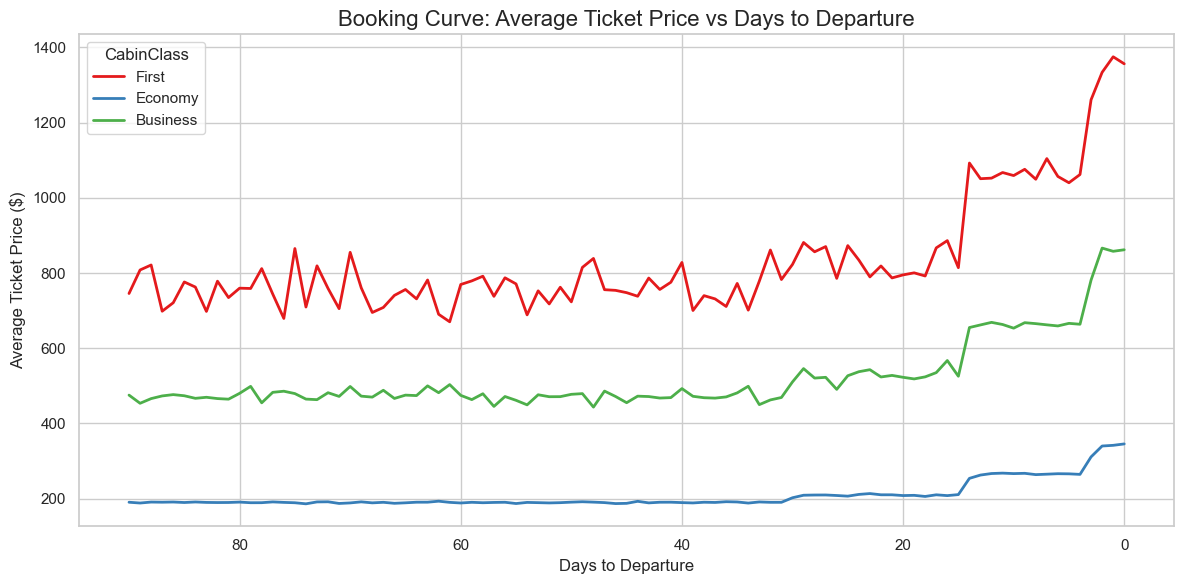

In [4]:
# Plot 1: Yield Management (Price vs Days to Departure)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=booking_curve, 
    x='DaysToDeparture', 
    y='AvgTicketPrice', 
    hue='CabinClass', 
    linewidth=2,
    palette='Set1'
)
plt.gca().invert_xaxis() # 90 days to 0 days
plt.title('Booking Curve: Average Ticket Price vs Days to Departure', fontsize=16)
plt.ylabel('Average Ticket Price ($)', fontsize=12)
plt.xlabel('Days to Departure', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'booking_curve_price.png'))
plt.show()

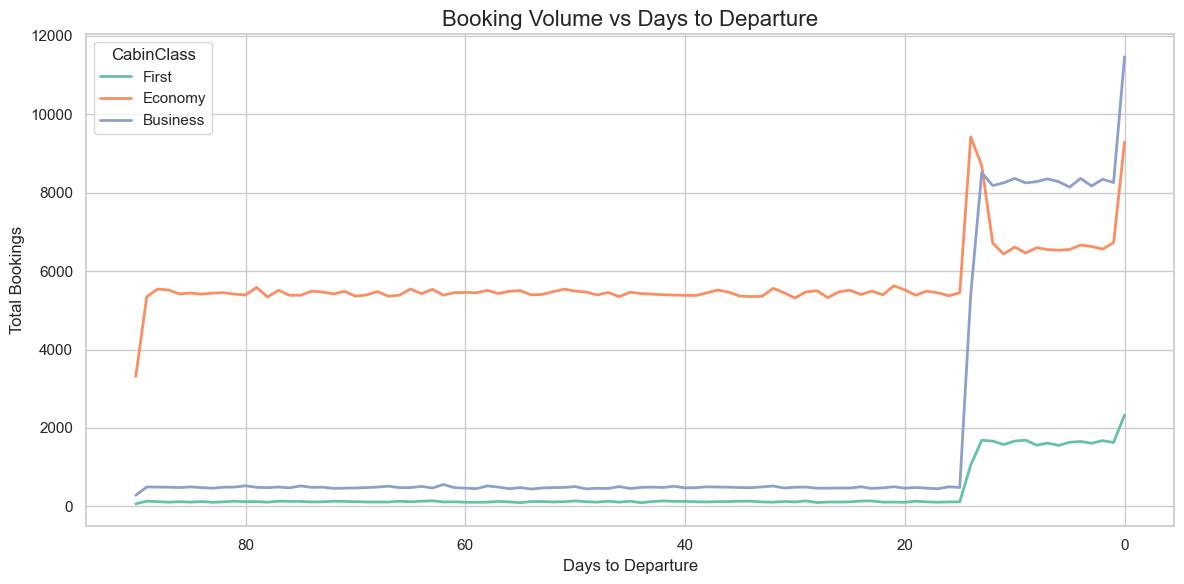

Pricing & Demand analysis complete and figures saved.


In [5]:
# Plot 2: Demand Volume vs Days to Departure
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=booking_curve, 
    x='DaysToDeparture', 
    y='BookingVolume', 
    hue='CabinClass', 
    linewidth=2,
    palette='Set2'
)
plt.gca().invert_xaxis()
plt.title('Booking Volume vs Days to Departure', fontsize=16)
plt.ylabel('Total Bookings', fontsize=12)
plt.xlabel('Days to Departure', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'booking_curve_volume.png'))
plt.show()

print("Pricing & Demand analysis complete and figures saved.")